In [1]:
import requests
import pandas as pd

url = 'https://data.lacity.org/resource/5m3t-xjex.json?$select=ZIP_code,CD,permit_sub_type,permit_nbr,issue_date&$where=permit_type=%27HVAC%27&$limit=150000'

resp = requests.get(url)
data_frame =pd.DataFrame(resp.json())
data_frame.shape

(148630, 5)

In [2]:
data_frame.head()

,ZIP_code,CD,permit_sub_type,permit_nbr,issue_date
0,90046,5,1 or 2 Family Dwelling,15044-90000-13756,2015-12-29T00:00:00.000
1,90049,11,Apartment,18044-90000-09146,2018-07-30T00:00:00.000
2,90008,10,Apartment,19044-30000-03279,2019-07-29T00:00:00.000
3,91326,12,1 or 2 Family Dwelling,17044-90000-14527,2017-11-19T00:00:00.000
4,90066,11,Commercial,15044-90000-06926,2015-07-13T00:00:00.000


In [3]:
data_frame.dtypes

ZIP_code           str
CD                 str
permit_sub_type    str
permit_nbr         str
issue_date         str
dtype: object

In [4]:
data_frame['issue_date'] = pd.to_datetime(data_frame['issue_date'])
data_frame.dtypes

ZIP_code                      str
CD                            str
permit_sub_type               str
permit_nbr                    str
issue_date         datetime64[us]
dtype: object

In [5]:
data_frame['issue_date'].min(), data_frame['issue_date'].max()

(Timestamp('2010-01-03 00:00:00'), Timestamp('2019-12-31 00:00:00'))

In [6]:
data_frame.isnull().sum()

ZIP_code            13
CD                 113
permit_sub_type      0
permit_nbr           0
issue_date           0
dtype: int64

In [7]:
data_frame.isna().sum()

ZIP_code            13
CD                 113
permit_sub_type      0
permit_nbr           0
issue_date           0
dtype: int64

In [8]:
data_frame['permit_nbr'].duplicated().sum()

np.int64(0)

In [9]:
import requests
import pandas as pd

url = 'https://data.lacity.org/resource/67is-svtd.json?$select=ZIP_code,CD,permit_sub_type,permit_nbr,issue_date&$where=permit_type=%27HVAC%27&$limit=100000'
response = requests.get(url)
df = pd.DataFrame(response.json())
df.shape

(92219, 5)

In [10]:
df['issue_date'] = pd.to_datetime(df['issue_date'])

In [11]:
df['issue_date'].min(), df['issue_date'].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2026-09-12 00:00:00'))

In [12]:
df.isnull().sum()

ZIP_code             2
CD                 339
permit_sub_type      0
permit_nbr           0
issue_date           0
dtype: int64

In [13]:
df['permit_nbr'].duplicated().sum()

np.int64(0)

In [14]:
df.head()

,ZIP_code,CD,permit_sub_type,permit_nbr,issue_date
0,91602,2,1 or 2 Family Dwelling,26044-90000-05673,2026-05-22
1,90044,8,Apartment,22044-30000-00217,2022-01-10
2,90744,15,1 or 2 Family Dwelling,22044-90000-12574,2022-10-07
3,90033,14,1 or 2 Family Dwelling,25044-90000-02119,2025-03-09
4,90025,11,Apartment,23044-10000-19858,2023-08-14


In [15]:
df.dtypes

ZIP_code                      str
CD                            str
permit_sub_type               str
permit_nbr                    str
issue_date         datetime64[us]
dtype: object

In [16]:
df.isna().sum()

ZIP_code             2
CD                 339
permit_sub_type      0
permit_nbr           0
issue_date           0
dtype: int64

In [17]:
whole_f = pd.concat([data_frame, df], ignore_index = True)

In [18]:
whole_f.shape

(240849, 5)

In [19]:
whole_f['permit_nbr'].is_unique

True

In [20]:
whole_f.head()

,ZIP_code,CD,permit_sub_type,permit_nbr,issue_date
0,90046,5,1 or 2 Family Dwelling,15044-90000-13756,2015-12-29
1,90049,11,Apartment,18044-90000-09146,2018-07-30
2,90008,10,Apartment,19044-30000-03279,2019-07-29
3,91326,12,1 or 2 Family Dwelling,17044-90000-14527,2017-11-19
4,90066,11,Commercial,15044-90000-06926,2015-07-13


In [21]:
whole_f = whole_f.set_index('issue_date').sort_index()


In [22]:
weekly = whole_f.resample('W-SUN').size()

In [23]:
weekly.head()

issue_date
2010-01-03      1
2010-01-10    265
2010-01-17    261
2010-01-24    196
2010-01-31    253
Freq: W-SUN, dtype: int64

In [24]:
weekly.tail()

issue_date
2026-08-16    433
2026-08-23    385
2026-08-30    372
2026-09-06    358
2026-09-13    293
Freq: W-SUN, dtype: int64

In [25]:
whole_f.index.max()

Timestamp('2026-09-12 00:00:00')

In [26]:
weekly = weekly.drop('2010-01-03')

In [27]:
weekly.tail()

issue_date
2026-08-16    433
2026-08-23    385
2026-08-30    372
2026-09-06    358
2026-09-13    293
Freq: W-SUN, dtype: int64

In [28]:
weekly.shape

(871,)

<Axes: xlabel='issue_date'>

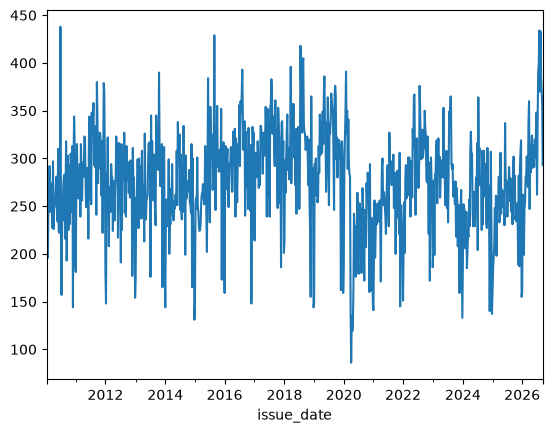

In [29]:
weekly.plot()

<Axes: xlabel='issue_date'>

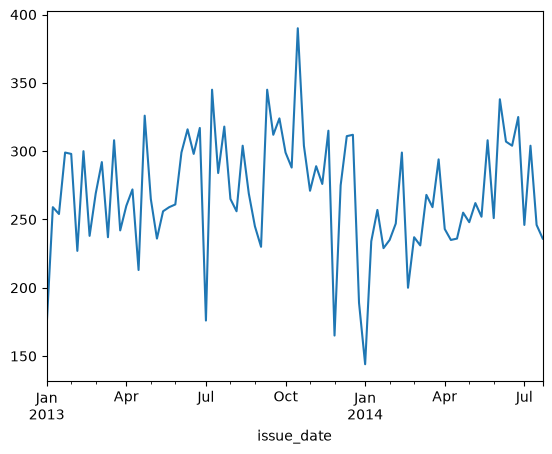

In [30]:
weekly['2013-01-01':'2014-08-01'].plot()

<Axes: xlabel='issue_date'>

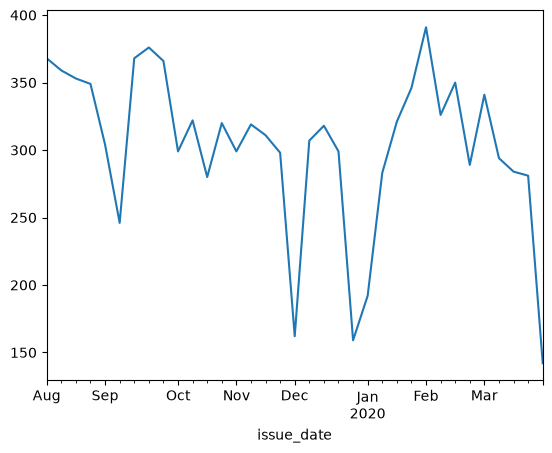

In [31]:
weekly['2019-08':'2020-03'].plot()

In [32]:
weekly.nsmallest(15)

issue_date
2020-04-05     86
2020-04-19    119
2020-04-26    126
2014-12-28    131
2023-12-31    133
2020-04-12    135
2024-12-29    137
2024-12-01    140
2021-01-03    141
2020-03-29    142
2010-11-28    144
2014-01-05    144
2018-12-30    144
2021-11-28    145
2015-01-04    146
dtype: int64

In [33]:
weekly.mean()

np.float64(276.5189437428243)

<Axes: xlabel='issue_date'>

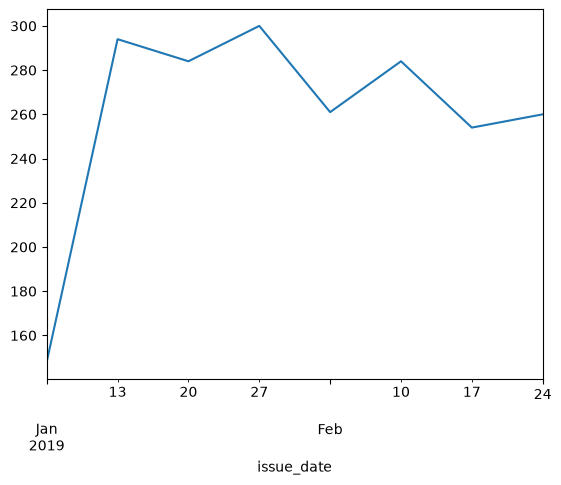

In [34]:
weekly['2019-01':'2019-02'].plot()

In [35]:
weekly.index.year

Index([2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010,
       ...
       2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026],
      dtype='int32', name='issue_date', length=871)

In [36]:
weekly.index.month

Index([1, 1, 1, 1, 2, 2, 2, 2, 3, 3,
       ...
       7, 7, 7, 8, 8, 8, 8, 8, 9, 9],
      dtype='int32', name='issue_date', length=871)

In [37]:
weekly_labeled = weekly.to_frame('count')

In [38]:
weekly_labeled.head()

,count
issue_date,
2010-01-10,265
2010-01-17,261
2010-01-24,196
2010-01-31,253
2010-02-07,259


In [39]:
weekly_labeled = pd.DataFrame({
  'month' : weekly_labeled.index.month,
  'year' : weekly_labeled.index.year,
  'count' : weekly_labeled['count']
})

In [40]:
weekly_labeled.head()

,month,year,count
issue_date,,,
2010-01-10,1,2010,265
2010-01-17,1,2010,261
2010-01-24,1,2010,196
2010-01-31,1,2010,253
2010-02-07,2,2010,259


In [41]:
pivot = weekly_labeled.pivot_table(index = 'month', columns = 'year', values= 'count', aggfunc='mean')

In [42]:
pivot

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
month,,,,,,,,,,,,,,,,,
1,243.75,261.60,242.80,246.25,216.00,226.00,262.40,262.00,269.25,256.50,285.50,202.60,219.00,229.20,235.50,187.25,219.00
2,261.00,264.00,247.50,265.75,245.25,255.75,279.75,292.00,317.75,264.75,339.00,242.50,274.25,291.00,210.25,235.50,266.00
3,264.50,286.00,274.25,269.60,257.80,239.60,296.50,310.00,320.50,316.40,268.40,244.00,295.25,305.00,225.60,255.60,310.00
4,244.50,305.50,251.60,267.75,242.25,262.25,287.75,312.00,328.40,321.25,116.50,254.00,272.00,282.20,310.50,263.50,287.50
5,273.20,280.60,301.25,254.00,267.50,260.40,295.60,326.75,305.75,357.00,207.60,253.80,333.20,303.25,243.25,258.00,305.60
6,281.50,283.75,267.00,298.20,305.00,310.00,292.75,300.00,306.00,304.60,210.75,263.25,283.75,265.50,266.80,278.20,323.00
7,222.00,315.80,266.80,280.75,258.00,300.25,344.60,333.60,329.80,313.25,222.25,281.25,311.60,301.60,293.00,267.00,345.75
8,263.40,319.00,286.25,273.50,286.60,323.80,342.50,346.75,380.25,357.25,226.40,287.60,309.25,328.00,262.00,265.40,398.80
9,269.25,319.25,279.40,291.20,257.25,293.00,304.00,316.75,322.20,332.00,218.75,277.50,318.00,273.00,282.00,272.75,325.50


In [43]:
avg = pivot.drop(columns=2026)

In [44]:
avg

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
month,,,,,,,,,,,,,,,,
1,243.75,261.60,242.80,246.25,216.00,226.00,262.40,262.00,269.25,256.50,285.50,202.60,219.00,229.20,235.50,187.25
2,261.00,264.00,247.50,265.75,245.25,255.75,279.75,292.00,317.75,264.75,339.00,242.50,274.25,291.00,210.25,235.50
3,264.50,286.00,274.25,269.60,257.80,239.60,296.50,310.00,320.50,316.40,268.40,244.00,295.25,305.00,225.60,255.60
4,244.50,305.50,251.60,267.75,242.25,262.25,287.75,312.00,328.40,321.25,116.50,254.00,272.00,282.20,310.50,263.50
5,273.20,280.60,301.25,254.00,267.50,260.40,295.60,326.75,305.75,357.00,207.60,253.80,333.20,303.25,243.25,258.00
6,281.50,283.75,267.00,298.20,305.00,310.00,292.75,300.00,306.00,304.60,210.75,263.25,283.75,265.50,266.80,278.20
7,222.00,315.80,266.80,280.75,258.00,300.25,344.60,333.60,329.80,313.25,222.25,281.25,311.60,301.60,293.00,267.00
8,263.40,319.00,286.25,273.50,286.60,323.80,342.50,346.75,380.25,357.25,226.40,287.60,309.25,328.00,262.00,265.40
9,269.25,319.25,279.40,291.20,257.25,293.00,304.00,316.75,322.20,332.00,218.75,277.50,318.00,273.00,282.00,272.75


In [45]:
monthly_avg = avg.mean(axis=1)
spread = (monthly_avg.max() - monthly_avg.min()) / monthly_avg.mean()
print(f"{spread:.0%}", monthly_avg.idxmax(), monthly_avg.idxmin())

23% 8 1


In [46]:
pivot

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
month,,,,,,,,,,,,,,,,,
1,243.75,261.60,242.80,246.25,216.00,226.00,262.40,262.00,269.25,256.50,285.50,202.60,219.00,229.20,235.50,187.25,219.00
2,261.00,264.00,247.50,265.75,245.25,255.75,279.75,292.00,317.75,264.75,339.00,242.50,274.25,291.00,210.25,235.50,266.00
3,264.50,286.00,274.25,269.60,257.80,239.60,296.50,310.00,320.50,316.40,268.40,244.00,295.25,305.00,225.60,255.60,310.00
4,244.50,305.50,251.60,267.75,242.25,262.25,287.75,312.00,328.40,321.25,116.50,254.00,272.00,282.20,310.50,263.50,287.50
5,273.20,280.60,301.25,254.00,267.50,260.40,295.60,326.75,305.75,357.00,207.60,253.80,333.20,303.25,243.25,258.00,305.60
6,281.50,283.75,267.00,298.20,305.00,310.00,292.75,300.00,306.00,304.60,210.75,263.25,283.75,265.50,266.80,278.20,323.00
7,222.00,315.80,266.80,280.75,258.00,300.25,344.60,333.60,329.80,313.25,222.25,281.25,311.60,301.60,293.00,267.00,345.75
8,263.40,319.00,286.25,273.50,286.60,323.80,342.50,346.75,380.25,357.25,226.40,287.60,309.25,328.00,262.00,265.40,398.80
9,269.25,319.25,279.40,291.20,257.25,293.00,304.00,316.75,322.20,332.00,218.75,277.50,318.00,273.00,282.00,272.75,325.50


In [47]:
peaks = pivot.idxmax(axis=0)


In [50]:
peaks

year
2010    12
2011    12
2012     5
2013    10
2014     6
2015     8
2016     7
2017     8
2018     8
2019     8
2020     2
2021     8
2022     5
2023     8
2024     4
2025     6
2026     8
dtype: int32

In [59]:
pivot.loc[:,2010:2013]

year,2010,2011,2012,2013
month,,,,
1,243.75,261.60,242.80,246.25
2,261.00,264.00,247.50,265.75
3,264.50,286.00,274.25,269.60
4,244.50,305.50,251.60,267.75
5,273.20,280.60,301.25,254.00
6,281.50,283.75,267.00,298.20
7,222.00,315.80,266.80,280.75
8,263.40,319.00,286.25,273.50
9,269.25,319.25,279.40,291.20
